# Graph Neural Network

The capacity of Graph Neural Networks (GNN) to evaluate graph structure data has recently attracted a lot of interest. An accessible introduction to the Graph Neural Network is provided in this article. It discusses specific graph theories to make graphs easier to grasp and to address issues with graph analysis.

A graph is a data structure consisting of two components: vertices, and edges. It is used as a mathematical structure to analyze the pair-wise relationship between objects and entities. Typically, a graph is defined as G=(V, E), where V is a set of nodes and E is the edges between them.

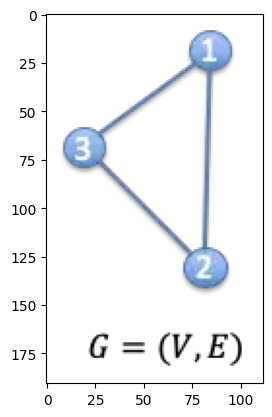

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('Graph.png')
imgplot = plt.imshow(img)
plt.show()

A graph is often represented by an Adjacency matrix, A. If a graph has N nodes, then A has a dimension of (NxN). People sometimes provide another feature matrix to describe the nodes in the graph. If each node has F numbers of features, then the feature matrix X has a dimension of (NxF).

A neural network that can be directly applied to graphs is known as a "graph neural network." It offers a practical method for prediction tasks at the node, edge, and graph levels.

$ \ $

There are mainly three types of graph neural networks in the literature:

$ \ $


**Recurrent Graph Neural Network**

**Spatial Convolutional Network**

**Spectral Convolutional Network**

### What Can GNN do?

The problems that GNN solve can be broadly classified into three categories:

$ \ $

- Node Classification
- Link Prediction
- Graph Classification

$ \ $

The objective of node classification is to forecast the node embedding for each node in a graph. Typically, only a portion of the graph is labelled during the semi-supervised training process for this kind of problem. Citation networks, Reddit postings, Youtube videos, and Facebook friend connections are a few examples of typical applications for node classification.

$ \ $

Understanding the connections between objects in graphs is necessary for link prediction, which asks whether two things are connected. A recommender system's job is to predict the users' preferences and adjust the recommender system to push more relevant products per the users' interests.

$ \ $

Graph classification aims to divide the entire graph into various categories. The aim shifts to the graph domain, although it is comparable to picture categorization. Graph classification can solve different industrial challenges, such as those in chemistry, biomedicine, and physics, where the model is given a molecular structure and asked to categorize the target into functional categories. It expedites the examination of any structured data type, including atom and molecule data.

In [2]:
import time

In [3]:
start = time.time()

In [4]:
!python -c "import torch; print(torch.__version__)"

2.6.0+cu124


In [5]:
!python -c "import torch; print(torch.version.cuda)"

12.4


In [6]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.4 MB/s eta 0:00:00


In [7]:
%matplotlib inline

import numpy as np
import pandas as pd
import math
import json
import os
import collections

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.animation as animation
import itertools
from itertools import combinations


import sklearn
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn import metrics

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.data import DataLoader as DataLoaderGraph
from torch_geometric.data import Dataset as DatasetGraph
from torch_geometric.data import Batch as BatchGraph

#from torch_geometric.transforms import AddTrainValTestMask as masking

from torch_geometric.nn import GCNConv, BatchNorm, SAGEConv, SGConv, ChebConv
from torch_geometric.utils.convert import to_networkx

import networkx as nx

In [8]:
with open("musae_git_features.json") as json_data:
    data_raw = json.load(json_data)

edges = pd.read_csv("musae_git_edges.csv")
target_df = pd.read_csv("musae_git_target.csv")#.to_numpy()[:,2]

In [9]:
print("5 top nodes labels")
print(target_df.head(5).to_markdown())
print()
print("5 last nodes")
print(target_df.tail(5).to_markdown())

5 top nodes labels
|    |   id | name         |   ml_target |
|---:|-----:|:-------------|------------:|
|  0 |    0 | Eiryyy       |           0 |
|  1 |    1 | shawflying   |           0 |
|  2 |    2 | JpMCarrilho  |           1 |
|  3 |    3 | SuhwanCha    |           0 |
|  4 |    4 | sunilangadi2 |           1 |

5 last nodes
|       |    id | name           |   ml_target |
|------:|------:|:---------------|------------:|
| 37695 | 37695 | shawnwanderson |           1 |
| 37696 | 37696 | kris-ipeh      |           0 |
| 37697 | 37697 | qpautrat       |           0 |
| 37698 | 37698 | Injabie3       |           1 |
| 37699 | 37699 | caseycavanagh  |           0 |


In [10]:
feats=[]
feat_counts=[]
for i in range(len(data_raw)):
    feat_counts+=[len(data_raw[str(i)])]
    feats+=data_raw[str(i)]

print("5 top nodes labels")
print(target_df.head(5).to_markdown())
print()
print("5 last nodes")
print(target_df.tail(5).to_markdown())

5 top nodes labels
|    |   id | name         |   ml_target |
|---:|-----:|:-------------|------------:|
|  0 |    0 | Eiryyy       |           0 |
|  1 |    1 | shawflying   |           0 |
|  2 |    2 | JpMCarrilho  |           1 |
|  3 |    3 | SuhwanCha    |           0 |
|  4 |    4 | sunilangadi2 |           1 |

5 last nodes
|       |    id | name           |   ml_target |
|------:|------:|:---------------|------------:|
| 37695 | 37695 | shawnwanderson |           1 |
| 37696 | 37696 | kris-ipeh      |           0 |
| 37697 | 37697 | qpautrat       |           0 |
| 37698 | 37698 | Injabie3       |           1 |
| 37699 | 37699 | caseycavanagh  |           0 |


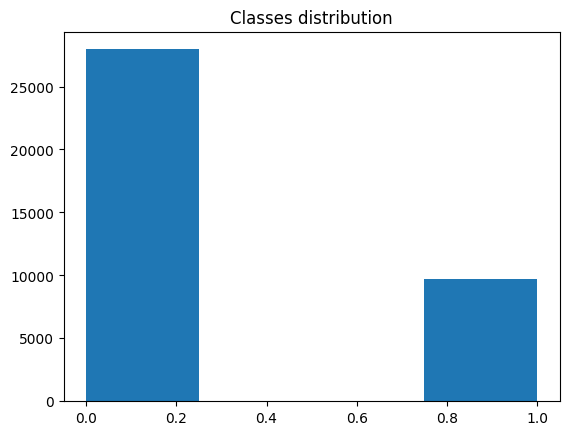

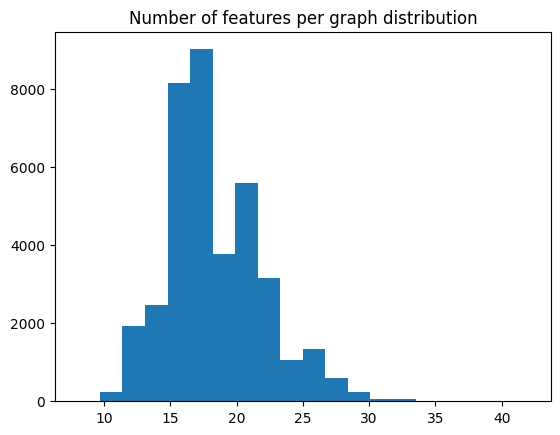

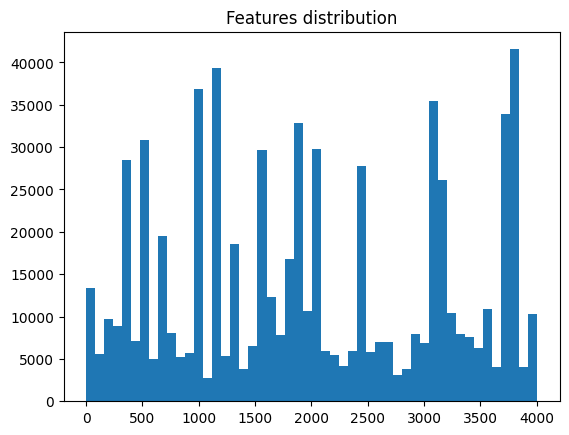

In [11]:
plt.hist(target_df.ml_target,bins=4,);
plt.title("Classes distribution")
plt.show()

plt.hist(feat_counts,bins=20)
plt.title("Number of features per graph distribution")
plt.show()

plt.hist(feats,bins=50)
plt.title("Features distribution")
plt.show()

In [12]:
counter=collections.Counter(feats)
print(list(counter.keys())[:10])
print(list(counter.values())[:10])
print(list(counter.keys())[-10:])
print(list(counter.values())[-10:])
#data_encoded

[1574, 3773, 3571, 2672, 2478, 2534, 3129, 3077, 1171, 2045]
[5045, 12726, 2486, 298, 165, 510, 22075, 28188, 24958, 21449]
[936, 172, 875, 3548, 2745, 793, 1941, 464, 2616, 3124]
[1, 2, 1, 2, 1, 1, 1, 1, 1, 1]


In [13]:
def encode_data(light=False,n=60):
    if light==True:
        nodes_included=n
    elif light==False:
        nodes_included=len(data_raw)

    data_encoded={}
    for i in range(nodes_included):#
        one_hot_feat=np.array([0]*(max(feats)+1))
        this_feat=data_raw[str(i)]
        one_hot_feat[this_feat]=1
        data_encoded[str(i)]=list(one_hot_feat)

    if light==True:
        sparse_feat_matrix=np.zeros((1,max(feats)+1))
        for j in range(nodes_included):
            temp=np.array(data_encoded[str(j)]).reshape(1,-1)
            sparse_feat_matrix=np.concatenate((sparse_feat_matrix,temp),axis=0)
        sparse_feat_matrix=sparse_feat_matrix[1:,:]
        return(data_encoded,sparse_feat_matrix)
    elif light==False:
        return(data_encoded, None)

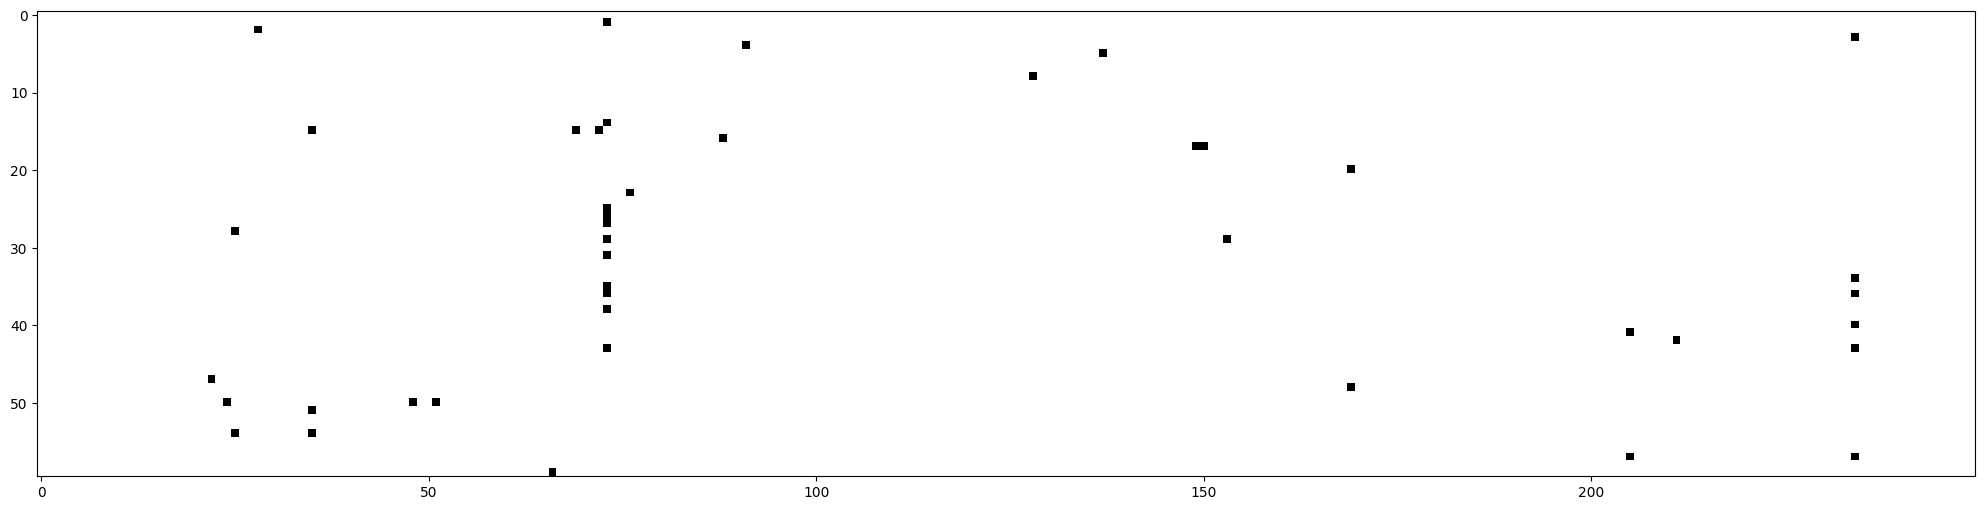

In [14]:
data_encoded_vis,sparse_feat_matrix_vis=encode_data(light=True,n=60)
plt.figure(figsize=(25,25));
plt.imshow(sparse_feat_matrix_vis[:,:250],cmap='Greys');
#plt.grid()

In [15]:
def construct_graph(data_encoded,light=False):
    node_features_list=list(data_encoded.values())
    node_features=torch.tensor(node_features_list)
    node_labels=torch.tensor(target_df['ml_target'].values)
    edges_list=edges.values.tolist()
    edge_index01=torch.tensor(edges_list, dtype = torch.long).T
    edge_index02=torch.zeros(edge_index01.shape, dtype = torch.long)#.T
    edge_index02[0,:]=edge_index01[1,:]
    edge_index02[1,:]=edge_index01[0,:]
    edge_index0=torch.cat((edge_index01,edge_index02),axis=1)
    g = Data(x=node_features, y=node_labels, edge_index=edge_index0)
    g_light = Data(x=node_features[:,0:2],
                     y=node_labels   ,
                     edge_index=edge_index0[:,:55])
    if light:
        return(g_light)
    else:
        return(g)

In [16]:
#g_top_draw = Data(x=node_features, y=node_labels, edge_index=edge_index0)

def draw_graph(data0):
    #node_labels=data0.y
    if data0.num_nodes>100:
        print("This is a big graph, can not plot...")
        return

    else:
        data_nx = to_networkx(data0)
        node_colors=data0.y[list(data_nx.nodes)]
        pos= nx.spring_layout(data_nx,scale =1)
        plt.figure(figsize=(12,8))
        nx.draw(data_nx, pos,  cmap=plt.get_cmap('Set1'),
                node_color =node_colors,node_size=600,connectionstyle="angle3",
                width =1, with_labels = False, edge_color = 'k', arrowstyle = "-")

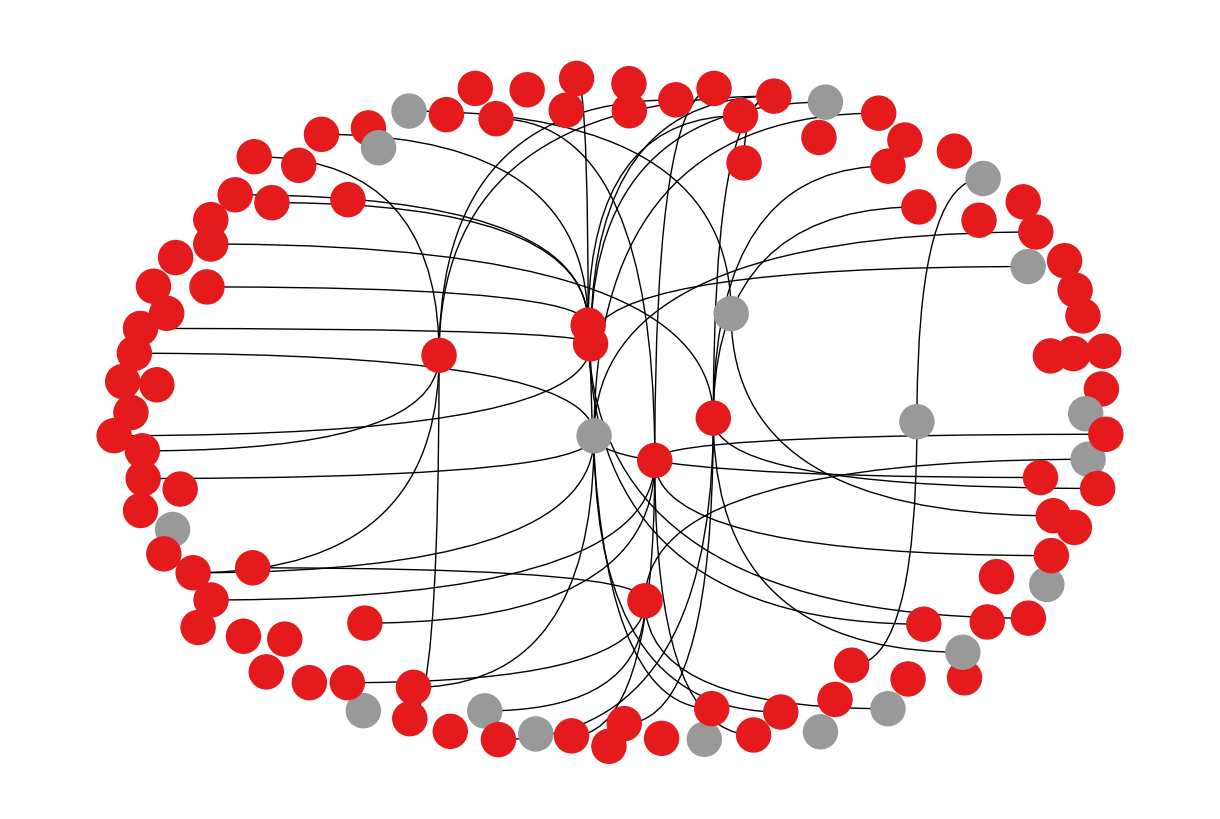

In [17]:
g_sample=construct_graph(data_encoded=data_encoded_vis,light=True)
draw_graph(g_sample)

In [18]:
data_encoded,_=encode_data(light=False)

In [19]:
g=construct_graph(data_encoded=data_encoded,light=False)

In [20]:
print(g)

Data(x=[37700, 4005], edge_index=[2, 578006], y=[37700])


In [21]:
import torch_geometric.transforms as T

In [22]:
import torch_geometric.transforms as T
msk=T.RandomNodeSplit(split="train_rest", num_splits = 1, num_val = 0.3, num_test= 0.6)
g=msk(g)
print(g)
print()
print("training samples",torch.sum(g.train_mask).item())
print("validation samples",torch.sum(g.val_mask ).item())
print("test samples",torch.sum(g.test_mask ).item())

Data(x=[37700, 4005], edge_index=[2, 578006], y=[37700], train_mask=[37700], val_mask=[37700], test_mask=[37700])

training samples 3770
validation samples 11310
test samples 22620


In [23]:
class SocialGNN(torch.nn.Module):
    def __init__(self,num_of_feat,f):
        super(SocialGNN, self).__init__()


        self.conv1 = GCNConv(num_of_feat, f)

        self.conv2 = GCNConv(f, 2)


    def forward(self, data):
        x = data.x.float()
        edge_index =  data.edge_index

        x = self.conv1(x=x, edge_index=edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        return x

In [24]:
def masked_loss(predictions,labels,mask):
    mask=mask.float()
    mask=mask/torch.mean(mask)
    loss=criterion(predictions,labels)
    loss=loss*mask
    loss=torch.mean(loss)
    return (loss)

In [25]:
def masked_accuracy(predictions,labels,mask):
    mask=mask.float()
    mask/=torch.mean(mask)
    accuracy=(torch.argmax(predictions,axis=1)==labels).long()
    accuracy=mask*accuracy
    accuracy=torch.mean(accuracy)
    return (accuracy)

In [26]:
def train_social(net,data,epochs=10,lr=0.01):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr) # 00001
    best_accuracy=0.0

    train_losses=[]
    train_accuracies=[]

    val_losses=[]
    val_accuracies=[]

    test_losses=[]
    test_accuracies=[]

    for ep in range(epochs+1):
        optimizer.zero_grad()
        out=net(data)
        loss=masked_loss(predictions=out,
                         labels=data.y,
                         mask=data.train_mask)
        loss.backward()
        optimizer.step()
        train_losses+=[loss]
        train_accuracy=masked_accuracy(predictions=out,
                                       labels=data.y,
                                       mask=data.train_mask)
        train_accuracies+=[train_accuracy]

        val_loss=masked_loss(predictions=out,
                             labels=data.y,
                             mask=data.val_mask)
        val_losses+=[val_loss]

        val_accuracy=masked_accuracy(predictions=out,
                                     labels=data.y,
                                     mask=data.val_mask)
        val_accuracies+=[val_accuracy]

        test_accuracy=masked_accuracy(predictions=out,
                                      labels=data.y,
                                      mask=data.test_mask)
        test_accuracies+=[test_accuracy]
        if np.round(val_accuracy,4)> np.round(best_accuracy ,4):
            print("Epoch {}/{}, Train_Loss: {:.4f}, Train_Accuracy: {:.4f}, Val_Accuracy: {:.4f}, Test_Accuracy: {:.4f}"
                      .format(ep+1,epochs, loss.item(), train_accuracy, val_accuracy,  test_accuracy))
            best_accuracy=val_accuracy




    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    plt.plot(test_accuracies)
    plt.show()

    print("Best accuracy",best_accuracy)
    return(best_accuracy)

Epoch 1/150, Train_Loss: 0.7029, Train_Accuracy: 0.2716, Val_Accuracy: 0.2790, Test_Accuracy: 0.2770
Epoch 2/150, Train_Loss: 1.4188, Train_Accuracy: 0.7488, Val_Accuracy: 0.7421, Test_Accuracy: 0.7403
Epoch 3/150, Train_Loss: 0.6299, Train_Accuracy: 0.7488, Val_Accuracy: 0.7422, Test_Accuracy: 0.7405
Epoch 4/150, Train_Loss: 0.4540, Train_Accuracy: 0.7488, Val_Accuracy: 0.7423, Test_Accuracy: 0.7405
Epoch 5/150, Train_Loss: 0.5310, Train_Accuracy: 0.7488, Val_Accuracy: 0.7424, Test_Accuracy: 0.7405
Epoch 17/150, Train_Loss: 0.3996, Train_Accuracy: 0.8101, Val_Accuracy: 0.8067, Test_Accuracy: 0.8029
Epoch 18/150, Train_Loss: 0.3981, Train_Accuracy: 0.8337, Val_Accuracy: 0.8255, Test_Accuracy: 0.8220
Epoch 19/150, Train_Loss: 0.4031, Train_Accuracy: 0.8456, Val_Accuracy: 0.8437, Test_Accuracy: 0.8401
Epoch 20/150, Train_Loss: 0.4050, Train_Accuracy: 0.8552, Val_Accuracy: 0.8517, Test_Accuracy: 0.8500
Epoch 21/150, Train_Loss: 0.3984, Train_Accuracy: 0.8607, Val_Accuracy: 0.8562, Test_Ac

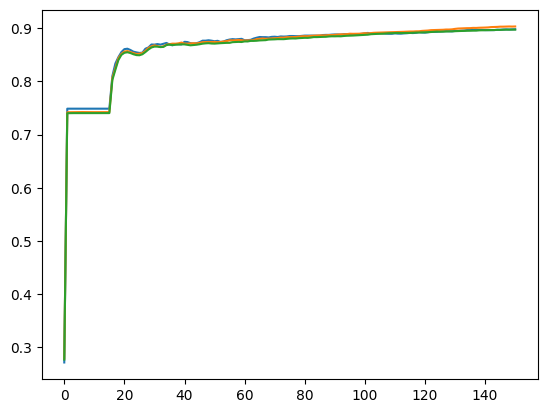

Best accuracy tensor(0.9034)


tensor(0.9034)

In [27]:
num_of_feat=g.num_node_features
net=SocialGNN(num_of_feat=num_of_feat,f=16)
criterion=nn.CrossEntropyLoss()
train_social(net,g,epochs=150,lr=0.1)

In [28]:
end = time.time()

In [29]:
delta = int(end - start)

In [31]:
hours = int(delta/3_600)
mins = int((delta - hours*3_600)/60)
secs = int(delta - hours*3_600 - mins*60)

In [32]:
print('Hours:', hours)
print('Minutes:', mins)
print('Seconds:', secs)

Hours: 0
Minutes: 10
Seconds: 42
